# FMRG Final Submission: Hierarchical Local Geometry Prediction

This executed notebook is the compact submission record for predicting spatially
varying DED track width, center, and left/right boundaries from the completed thermal
sequence. This primary model is an offline prediction after the scan completes.

**Evaluation protocol:** each of Tracks 8, 10, 14, and 21 is held out once. Feature
family, estimator, preprocessing, and calibration are selected by leave-one-track-out
validation using only the other three tracks. Headline metrics are unweighted means
across the four untouched outer tracks.

## Reproducibility

Recreate the tracked outputs from the official Zenodo release with:

```bash
PYTHONPATH=src LOKY_MAX_CPU_COUNT=1 MPLBACKEND=Agg               .venv/bin/python scripts/run_improvement_experiments.py               --raw-dir /path/to/extracted/zenodo/data               --cache-dir /path/to/cache               --output-dir results/improved_submission
```

The notebook reads the tracked outer-fold predictions and locked metrics so it can
execute without redistributing the large raw archives.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "results/improved_submission/metrics.json").exists():
    ROOT = ROOT.parent

RESULTS = ROOT / "results/improved_submission"
metrics = json.loads((RESULTS / "metrics.json").read_text())
predictions = pd.read_csv(RESULTS / "outer_fold_predictions.csv")
metrics["protocol"]

{'name': 'nested leave-one-track-out',
 'outer_tracks': [8, 10, 14, 21],
 'selection': 'inner leave-one-track-out on the other three tracks',
 'primary_metric': 'unweighted mean of per-track width MAE',
 'coverage_target': 0.9,
 'accuracy_tolerance_mm': 0.01,
 'thermal_sequence_scope': 'completed sequence',
 'prediction_mode': 'offline',
 'steady_state_x_mm': [24.0, 96.0],
 'random_seed': 42}

## Model: condition baseline plus local residual

A single regressor tends to blur two effects: the mean width shift between laser
conditions and the smaller spatial fluctuations within a track. The promoted model
separates them:

1. completed-sequence thermal summaries predict baseline center and baseline
   log-width;
2. frame-level thermal history predicts local center and log-width residuals;
3. width is reconstructed with an exponential transform, so it is positive; and
4. left/right boundaries are reconstructed from shared center and width, so they
   cannot cross.

The candidate ladder includes Ridge, elastic net, partial least squares,
spline-Ridge, and a low-capacity Gaussian process. Thermal descriptors include melt
pool shape, temperature distribution, gradients, asymmetry, cooling tail, motion,
persistence, and causal 5-, 10-, and 20-frame history. The primary model also uses
full-sequence robust normalization and condition summaries, so it is offline.

In [2]:
incumbent = metrics["incumbent"]["metrics"]
promoted = metrics["candidates"]["nested_metrics"]

rows = []
for name, values in [
    ("Direct Ridge incumbent", incumbent),
    ("Nested hierarchical selector", promoted),
]:
    rows.append(
        {
            "model": name,
            "track_balanced_width_MAE_mm": values["track_balanced_width_mae_mm"],
            "worst_track_MAE_mm": values["worst_track_width_mae_mm"],
            "mean_boundary_MAE_mm": values["mean_boundary_mae_mm"],
            "residual_correlation": values["residual_correlation"],
            "variation_std_ratio": values["variation_std_ratio"],
        }
    )
comparison = pd.DataFrame(rows).set_index("model")
comparison.round(4)

,track_balanced_width_MAE_mm,worst_track_MAE_mm,mean_boundary_MAE_mm,residual_correlation,variation_std_ratio
model,,,,,
Direct Ridge incumbent,0.1871,0.3080,0.1800,0.0547,0.2141
Nested hierarchical selector,0.1484,0.2008,0.1419,0.0859,0.3231


In [3]:
improvement = 100 * (
    incumbent["track_balanced_width_mae_mm"]
    - promoted["track_balanced_width_mae_mm"]
) / incumbent["track_balanced_width_mae_mm"]
worst_improvement = 100 * (
    incumbent["worst_track_width_mae_mm"]
    - promoted["worst_track_width_mae_mm"]
) / incumbent["worst_track_width_mae_mm"]
boundary_improvement = 100 * (
    incumbent["mean_boundary_mae_mm"]
    - promoted["mean_boundary_mae_mm"]
) / incumbent["mean_boundary_mae_mm"]
print(f"Track-balanced width MAE improvement: {improvement:.1f}%")
print(f"Worst-track MAE improvement: {worst_improvement:.1f}%")
print(f"Mean boundary MAE improvement: {boundary_improvement:.1f}%")

Track-balanced width MAE improvement: 20.7%
Worst-track MAE improvement: 34.8%
Mean boundary MAE improvement: 21.1%


## Four untouched outer tests

Each outer fold independently chooses its feature family and low-capacity estimator
using only the other three tracks. The final outer predictions are therefore the
honest output of nested selection, not one configuration tuned against all four
labels.

In [4]:
per_track = promoted["per_track"]
pd.DataFrame(
    [
        {
            "track": int(track),
            "width_MAE_mm": values["width_mae_mm"],
            "boundary_MAE_mm": values["mean_boundary_mae_mm"],
            "residual_correlation": values["residual_correlation"],
            "variation_std_ratio": values["variation_std_ratio"],
        }
        for track, values in per_track.items()
    ]
).sort_values("track").round(4)

,track,width_MAE_mm,boundary_MAE_mm,residual_correlation,variation_std_ratio
0,8,0.1129,0.0817,0.1725,0.6774
1,10,0.1195,0.1130,0.0210,0.3094
2,14,0.1605,0.1213,0.0483,0.1836
3,21,0.2008,0.2516,0.1018,0.1222


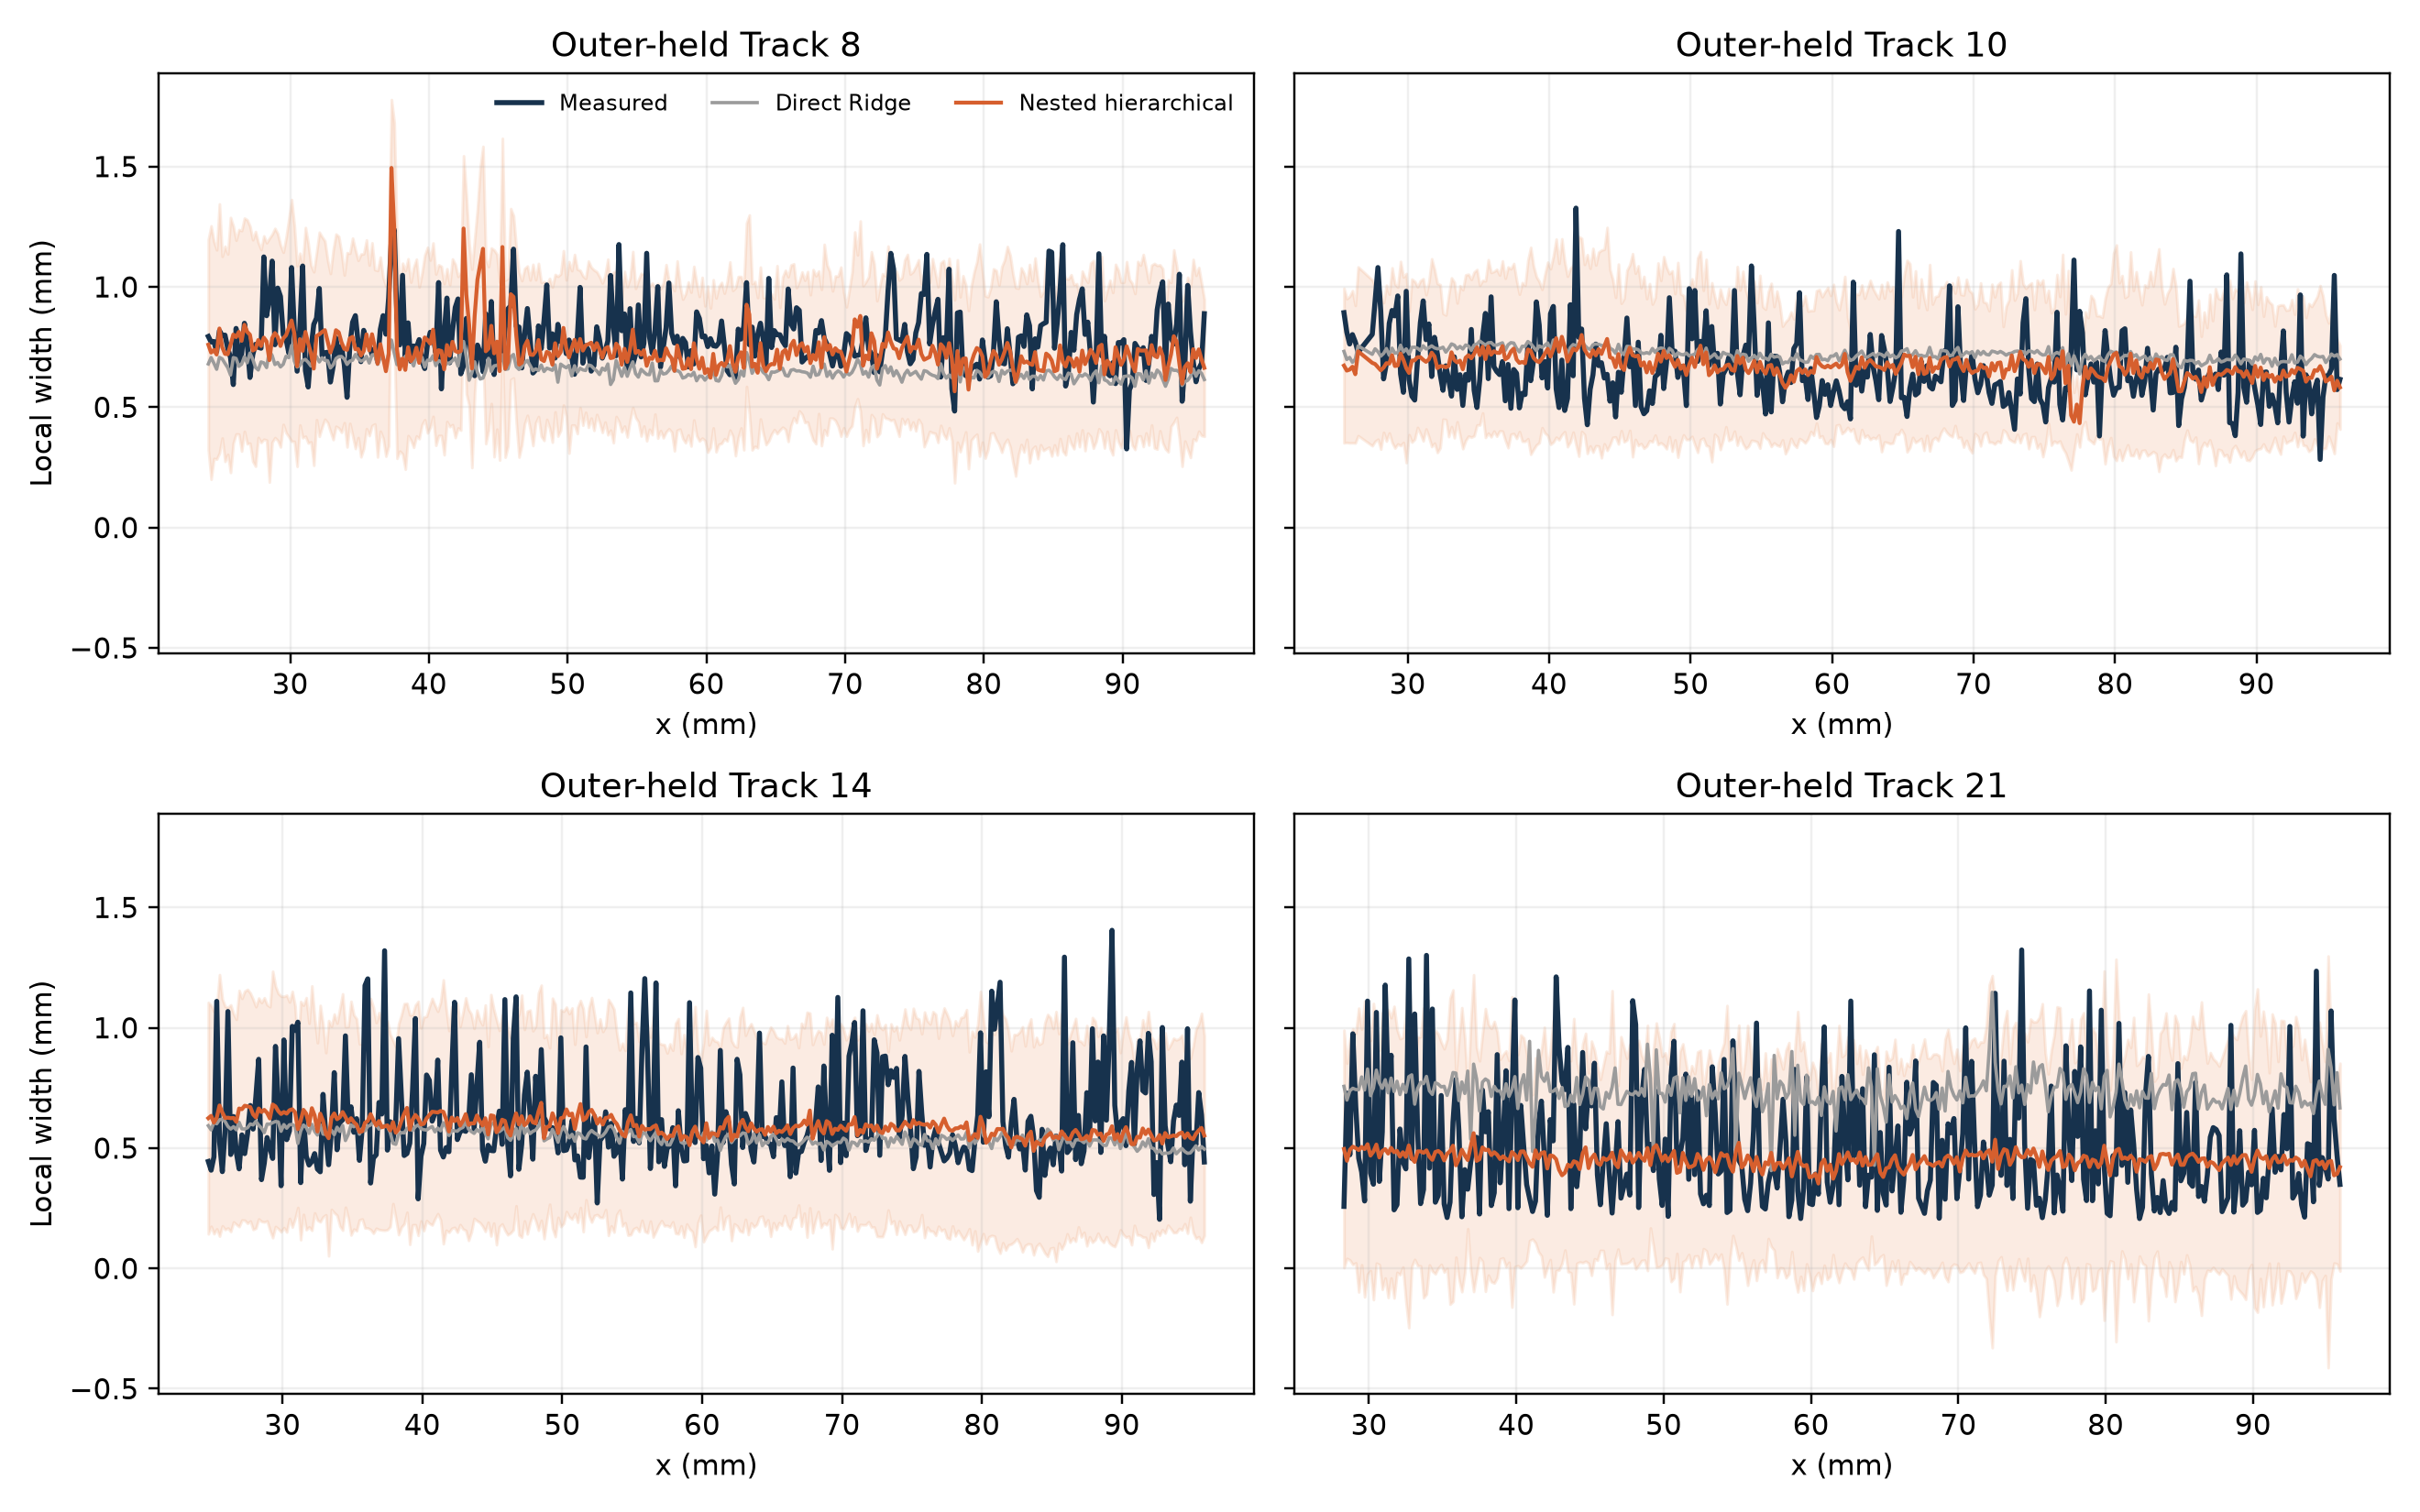

In [5]:
display(
    Image(
        filename=str(RESULTS / "figures/nested_outer_predictions.png"),
        width=1100,
    )
)

## Conditional uncertainty

Normalized conformal calibration scales intervals by predicted local difficulty.
For the primary offline model it is closer to the 90% target and narrower on average
than a single global interval. Interval width grows from easy to difficult regions.

In [6]:
uncertainty = metrics["uncertainty"]
summary = pd.DataFrame(
    [
        {"method": "conditional", **uncertainty["conditional"]},
        {"method": "global", **uncertainty["global"]},
    ]
).set_index("method")
display(summary.round(4))
display(
    pd.DataFrame(uncertainty["conditional_by_difficulty"])
    .T.rename_axis("difficulty")
    .round(4)
)

,coverage,mean_width_mm
method,,
conditional,0.9351,0.7801
global,0.9486,0.8771


,coverage,mean_width_mm
difficulty,,
low,0.9252,0.6295
medium,0.9465,0.7669
high,0.9336,0.9442


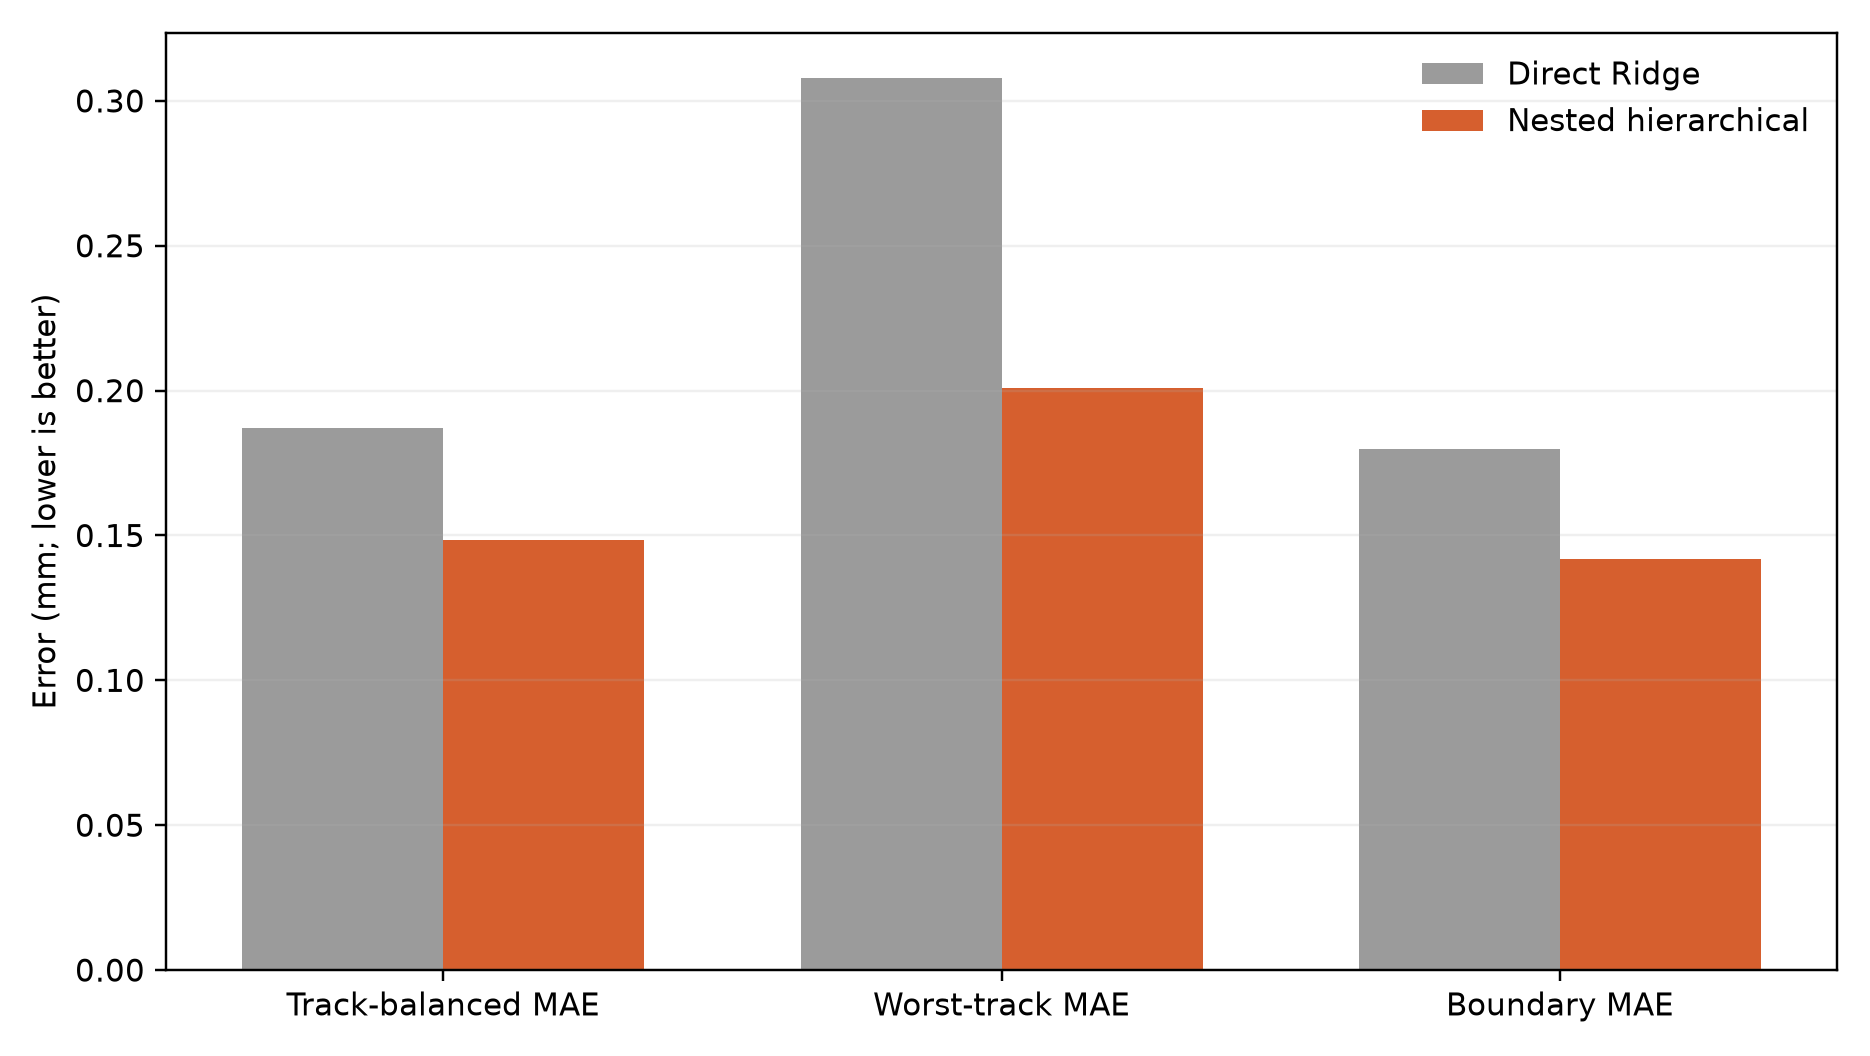

In [7]:
display(
    Image(
        filename=str(RESULTS / "figures/before_after_scorecard.png"),
        width=1000,
    )
)

## SEM ablation and interpretation

The available SEM is post-process and cannot exist at frame-time inference. It is
excluded from predictive candidates even when the processed center band is masked.
Therefore this submission makes no causal claim that pre-existing substrate texture
drives geometry.

Interpretable thermal links come from the selected descriptor families: track-level
hot area, maximum temperature, thermal mass, and cooling-tail summaries explain the
condition baseline; normalized local shape, temperature, asymmetry, and history
explain residual variation. These are predictive associations, not causal effects.

In [8]:
metrics["sem_ablation"]

{'source': 'post-process SEM with the processed center masked',
 'preprocess_sem_available': False,
 'eligible_for_prediction': False,
 'exclusion_reason': 'post-process imagery is unavailable at prediction time',
 'outer_folds_selecting_sem': 0,
 'selected_by_any_outer_fold': False,
 'causal_substrate_claim': False}

## Causal current-and-past-only ablation

The headline model is offline because full-sequence thermal summaries and robust
normalization are computed after the scan. To test online potential, the same
hierarchy is rerun with expanding summaries and normalization that use only the
current and earlier frames. Changing later thermal frames cannot change an earlier
causal-ablation prediction.

In [9]:
causal = metrics["causal_ablation"]
pd.Series(
    {
        "offline_primary_MAE_mm": promoted["track_balanced_width_mae_mm"],
        "causal_ablation_MAE_mm": causal["metrics"][
            "track_balanced_width_mae_mm"
        ],
        "offline_primary_R2": promoted["track_balanced_width_r2"],
        "causal_ablation_R2": causal["metrics"][
            "track_balanced_width_r2"
        ],
    }
).round(4)

offline_primary_MAE_mm    0.1484
causal_ablation_MAE_mm    0.1566
offline_primary_R2       -0.1345
causal_ablation_R2       -0.1816
dtype: float64

## Historical Track 21 benchmark

The earlier audited split achieved 0.139 mm Track 21 MAE versus 0.159 mm for the
original notebook. That number is retained only as a historical benchmark. Under the
stronger four-track nested protocol, Track 21 receives no special tuning and scores
0.201 mm. The two numbers answer different questions and must not be combined.

In [10]:
metrics["historical_benchmark"]

{'original_notebook_mae_mm': 0.1589159,
 'audited_ridge_mae_mm': 0.1393538,
 'mae_improvement_percent': 12.3097,
 'role': 'historical benchmark only; not used for model selection'}

## Honest conclusion

- The offline completed-sequence model improves four-track width MAE from **0.187 mm
  to 0.148 mm** (**20.7%**), worst-track MAE from **0.308 mm to 0.201 mm**
  (**34.8%**), and boundary MAE from **0.180 mm to 0.142 mm** (**21.1%**).
- Residual correlation improves from **0.055 to 0.086**, and predicted variation
  amplitude rises from **21% to 32%** of measured variation.
- Conditional intervals achieve **93.5%** coverage with **0.780 mm** mean width,
  versus **94.9%** and **0.877 mm** for the global interval.
- Track-balanced R-squared improves from **-0.55 to -0.13** but remains negative.
- The causal current-and-past-only ablation reaches **0.157 mm** MAE and **-0.18** R².

The primary model uses completed thermal inputs, not future geometry. No held-out
geometry, test-track labels, or post-process SEM enters prediction or selection.
This is an offline quality prediction, not an instantaneous or closed-loop controller.

The next decisive experiment is registered pre-process surface measurement across
more plates, powers, and repeats.

## Generative AI disclosure

Generative AI assisted with code review, test generation, debugging, and artifact
layout. Team members reviewed the resulting code and materials. Reported metrics were
produced by tracked analysis code and saved outer-fold predictions; AI did not supply
or alter experimental measurements.

## Sources

- Official dataset: https://doi.org/10.5281/zenodo.21285367
- Dataset paper: https://arxiv.org/abs/2607.07965
- Locked metrics: `results/improved_submission/metrics.json`
- Outer predictions: `results/improved_submission/outer_fold_predictions.csv`